# Your Name Here: Anish Hayman

# A3 LogisticRegression, Multi-layer Perceptron (MLP)

## 1. Load data and perform general EDA (3+2+1+3+6 = 15pts)

### 1.1 import libraries: numpy, matplotlib.pyplot and pandas. (1+1+1 = 3pts)

You can import other libraries below as needed in any block.

In [38]:
# TODO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1.2 import the data to a pandas dataframe and show the count of rows and columns (2pts)

In [39]:
# uncomment the following line if you are running this code in google colab and have uploaded the dataset to your drive
from google.colab import drive
drive.mount('/content/drive')

# TODO
file_name = '/content/drive/MyDrive/Colab Notebooks/Wine_Quality_Data.csv'
with open(file_name, 'r') as file:
  df = pd.read_csv(file_name)

rows = len(df.axes[0])
cols = len(df.axes[1])

print(df)
print("Num of rows: ", rows)
print("Num of columns: ", cols)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30           

### 1.3 Show if any column has null values. (1pt)

In [40]:
# TODO
print(df.isnull().sum())

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64


### 1.4 We will use the 'quality' column as our target label. Print the count of each label in the dataset (in percentage). Mention which quality scores are among top 3 by their counts. (3pts)

In [41]:
# TODO
print(df['quality'].value_counts() * 100 /len(df))
print("Labels 6, 5 and 7 are the top 3")

6    43.650916
5    32.907496
7    16.607665
4     3.324611
8     2.970602
3     0.461752
9     0.076959
Name: quality, dtype: float64
Labels 6, 5 and 7 are the top 3


### 1.5 Observe the correlation matrix for the columns. Name the pairs of columns with highest positive and highest negative correlations. (2+4 = 6pts) 

You can import and use seaborn here to visualize correlation matrix in a heatmap.

Highest positve correlation: Density and fixed_acidity
Lowest negative correlation: Density and alcohol


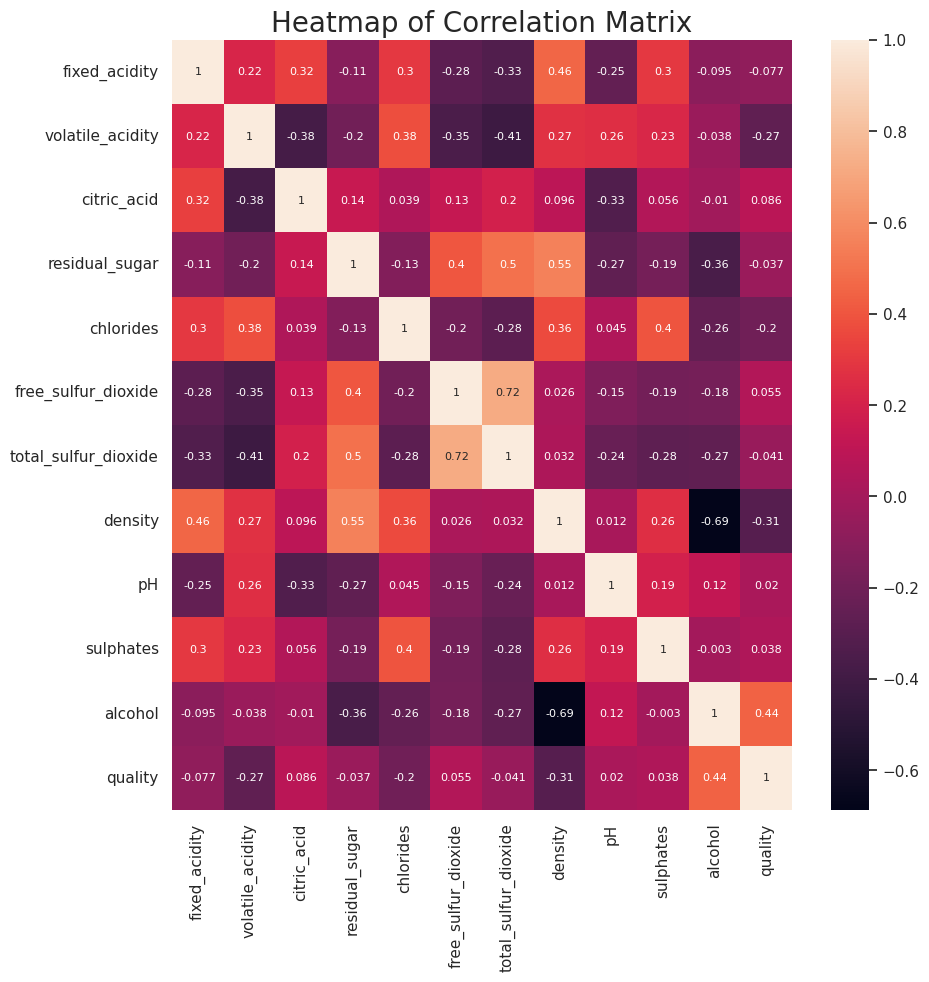

In [42]:
# TODO
import seaborn as sns
corr = df.corr()
sns.set(rc={'figure.figsize':(10,10)})
sns.heatmap(corr, xticklabels='auto', yticklabels='auto', annot=True, annot_kws={"fontsize":8})
plt.title('Heatmap of Correlation Matrix', fontsize = 20) 

print("Highest positve correlation: Density and fixed_acidity")
print("Lowest negative correlation: Density and alcohol")

## 2. Feature Selection and Preprocessing (2+2+3+3 = 10pts)

### 2.1 Drop the 'color' attribute from the dataframe. (2pts)

In [43]:
# TODO
df.drop(columns = ['color'], inplace=True)
df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### 2.2 Assign the 'quality' column to target label y, and all other columns to attribute matrix X (1+1 = 2pts)

In [44]:
# TODO
y = df['quality']
x = df.loc[:, df.columns!='quality']

print(x)
print(y)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free_sulfur_dioxide  

### 2.3 Use scikitlearn's Standard Scaler to scale the feature matrix X. (3pts)

In [45]:
# TODO
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)
print(x)

[[ 0.14247327  2.18883292 -2.19283252 ...  1.81308951  0.19309677
  -0.91546416]
 [ 0.45103572  3.28223494 -2.19283252 ... -0.11507303  0.99957862
  -0.58006813]
 [ 0.45103572  2.55330026 -1.91755268 ...  0.25811972  0.79795816
  -0.58006813]
 ...
 [-0.55179227 -0.6054167  -0.88525328 ... -1.42124765 -0.47897144
  -0.91546416]
 [-1.32319841 -0.30169391 -0.12823371 ...  0.75571005 -1.016626
   1.9354021 ]
 [-0.93749534 -0.78765037  0.42232597 ...  0.25811972 -1.41986693
   1.09691202]]


### 2.4 Split Dataset into Training and Test set. (3 pts)
Use 80:20 split for training and test. Also use stratified sampling to ensure balanced dataset.

In [46]:
# TODO
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y)

print(pd.value_counts(y_train))
print(pd.value_counts(y_test))

6    2269
5    1710
7     863
4     173
8     154
3      24
9       4
Name: quality, dtype: int64
6    567
5    428
7    216
4     43
8     39
3      6
9      1
Name: quality, dtype: int64


## 3. Logistic Regression from scratch (10+10+10+25+20 = 75pts)


In this section, you will write a logistic regression algorithm from scratch using python and numpy. You will first write some helper functions for transforming label encoding to one-hot encoding, for measuring the cross-entropy loss and predicting labels from test data. These functions will later be used in the logistic regression training and testing.   

### 3.1 The target label in our dataset is the 'quality' column. It consists of categorical values, label-encoded with 7 values in the range [3-9]. To perform a multiclass logistic regression, you need a function that takes a label matrix and converts it to One-hot encoded labels. (10pts)

Write the function below following the docstring. 

In [175]:
def onehot(y):
    """
    Converts an array of labels to one-hot encoding.

    Parameters:
    -----------
    y : numpy.ndarray
        An array of labels. It must have a shape of (n_samples, ).

    Returns:
    --------
    numpy.ndarray
        A matrix of one-hot encoding. It has a shape of (n_samples, n_classes).
    """
    
    # TODO

    #creating a 2D array filled with 0's
    encoded = np.zeros((y.size, y.max()-y.min()+1), dtype=int)

    #replacing 0 with a 1 at the index of the original array
    for i in range(7):
      encoded[np.arange(y.size),i] = 1 
    

    return encoded


### 3.2 For multi-class classification, you also need to measure cross-entropy loss. Cross-entropy loss is measured by the following formula:
$\text{Cross-Entropy Loss} = -\frac{1}{N} \sum_{i=1}^N \sum_{j=1}^n y_{ij} \log \hat{y}_{ij}$

Write a function that takes two matrices: one matrix of true labels $y_{ij}$, and one matrix of the predicted labels by your model $\hat{y}_{ij}$ (you are about to write the model function soon below), and returns the computed loss. **(10pts)**


In [115]:
def cross_entropy_loss(y_true, y_pred):
    """
    Computes the cross-entropy loss between the true labels and predicted labels.

    Parameters
    ----------
    y_true : numpy array
        Array of true labels with shape (m, n_classes).
    y_pred : numpy array
        Array of predicted labels with shape (m, n_classes).

    Returns
    -------
    float
        Cross-entropy loss between y_true and y_pred.

    Notes
    -----
    This function assumes that the labels are one-hot encoded.
    """
    
    # TODO
    loss = 0.0
    for i in range(len(y_true)):
      #loss = loss + np.dot(y_true[i], np.log(y_pred[i]))
      for j in range(y_true.shape[1]):
        loss = loss + np.dot(y_true[i][j], np.log(y_pred[i][j]))
    
    loss = (-1/y_true.shape[0]) * loss

    return loss
   

### 3.3 Write a function for softmax activation to compute probabilities from the linear score $z_i$. Softmax function uses the following formula:
$$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{k}e^{z_j}} , \text{for } i=1,2,3,...,k $$
where $z_i$ is the linear layer score for i-th input.   

**(10pts)**

In [88]:
def softmax(scores):
    """
    Compute the softmax of the given scores.

    Parameters:
    -----------
    scores : numpy.ndarray
        A 2D numpy array of shape (m, n), where m is the number of samples and n is the number of classes.

    Returns:
    --------
    probs : numpy.ndarray
        A 2D numpy array of shape (m, n) containing the probabilities of each sample belonging to each class.
    """
       
    # TODO
    prob = np.exp(scores) / np.sum(np.exp(scores))
    return prob


### 3.4 Model development (20+5 = 25pts)

**3.4.1** Write a function for the logistic regression algorithm. You will use the functions you have written above in this module. Recall that with gradient descent optimization, the computation loop goes as:
For each epoch:
1. Compute $scores = X_{train} W + b$ 
2. Compute probability = softmax(scores)
3. Compute Cross-entropy Loss
4. Compute gradients of the loss with respect to the weights and bias.

    Partial derivative of Loss with respect to Weight matrix:
    $$\frac{\partial L}{\partial W} = -\frac{1}{m} X^T \left(y - \hat{y}\right)$$

    Partial derivative of Loss with respect to Bias matrix:
    $$\frac{\partial L}{\partial b_j} = -\frac{1}{m} \sum_{i=1}^m \left(y_{ij} - p_{ij}\right) $$

5. Update the weights and biases
    $$ W = W - (learning\ rate * weight\ gradient)  $$
    $$ b = b - (learning\ rate * weight\ gradient)  $$

**(20pts)**

In [120]:
def logistic_regression(X_train, y_train, ):
    """
    Performs logistic regression using softmax activation and gradient descent optimizer to classify the input data.

    Parameters:
    -----------
    X_train : numpy.ndarray
        The input training data of shape (num_samples, num_features).
    y_train : numpy.ndarray
        The training labels of shape (num_samples,).

    Returns:
    --------
    W : numpy.ndarray
        The learned weights of shape (num_features, num_classes).
    b : numpy.ndarray
        The learned bias of shape (1, num_classes).
    loss_list : list
        The list of loss values at each epoch during training.
    """

    # get the number of samples and features from X_train (2pts)
    # TODO

    num_samples = X_train.shape[0]
    num_features = X_train.shape[1]

    # convert training labels to one-hot encoded labels (2pts)
    # TODO
    y_train2 = onehot(y_train)

    # get the number of target classes from y_train (2pts)
    # TODO
    num_classes = len(np.unique(y_train))

    # initialize the weights and bias with numpy arrays of zeros (1+1 = 2pts)
    # TODO
    weights = np.zeros([num_features, num_classes])
    bias = np.zeros([1, num_classes])
    
    # set hyperparameters (1+1 = 2pts)
    ## set a learning rate
    # TODO
    learn_rate =  0.1
    ## set the max number of epochs you want to train for
    # TODO
    epoch = 1000
    
    ## initialize a list to store the loss values (1pt)
    # TODO
    loss_list = []
    
    
    '''
    Write a for loop over epochs.
    In each epoch:
        compute the score for each class, 
        compute the softmax probabilities, 
        compute the cross-entropy loss, 
        compute the gradients of the loss with respect to the weights and bias, 
        update the weights and bias using the gradients and the learning rate.
    '''
    # (9pts)
    # TODO
        # compute the score (Z) for each class. 
        # TODO
    for i in range(epoch):

      scores = np.dot(X_train, weights) + bias
        
        # calculate the softmax probabilities
        # TODO
      probs = softmax(scores)
        # compute the cross-entropy loss
        # TODO
      loss_val = cross_entropy_loss(y_train2, probs)
      loss_list.insert(i, loss_val)
      #print('Cross Entropy Loss:')
      #print(loss_list)

        # compute the gradients of the loss with respect to the weights and bias
        # TODO
      gradient_weight = (-1/num_samples) * (x_train.transpose() @ (y_train2 - probs))
      gradient_bias = (-1/num_samples) * (np.sum(y_train2 - probs))

        # update the weights and bias using the gradients and the learning rate
        # TODO
      weights = weights - (learn_rate * gradient_weight)
      bias = bias - (learn_rate * gradient_bias)
        # For tracking progress, print the loss every 100 epochs
        # TODO
      if (i % 100 == 0) :
        print('Cross Entropy Loss:')
        print(loss_val)
      
    return weights, bias, loss_list



**3.4.2** Now that you have the model and the helper function, train the model with your prepared training dataset. Then plot the training loss curve. **(5pts)**

Cross Entropy Loss:
73.51222874845112
Cross Entropy Loss:
73.89042396226486
Cross Entropy Loss:
75.32537107490384
Cross Entropy Loss:
81.18319928280032
Cross Entropy Loss:
96.91379814923066
Cross Entropy Loss:
116.54635228094413
Cross Entropy Loss:
136.62017278387708
Cross Entropy Loss:
156.73270672850137
Cross Entropy Loss:
176.84891673295527
Cross Entropy Loss:
196.96553269844168


<ipython-input-115-decacb23725f>:25: RuntimeWarning: divide by zero encountered in log
  loss = loss + np.dot(y_true[i], np.log(y_pred[i]))
<ipython-input-88-5db50fb44d12>:17: RuntimeWarning: overflow encountered in exp
  prob = np.exp(scores) / np.sum(np.exp(scores))
<ipython-input-88-5db50fb44d12>:17: RuntimeWarning: invalid value encountered in true_divide
  prob = np.exp(scores) / np.sum(np.exp(scores))


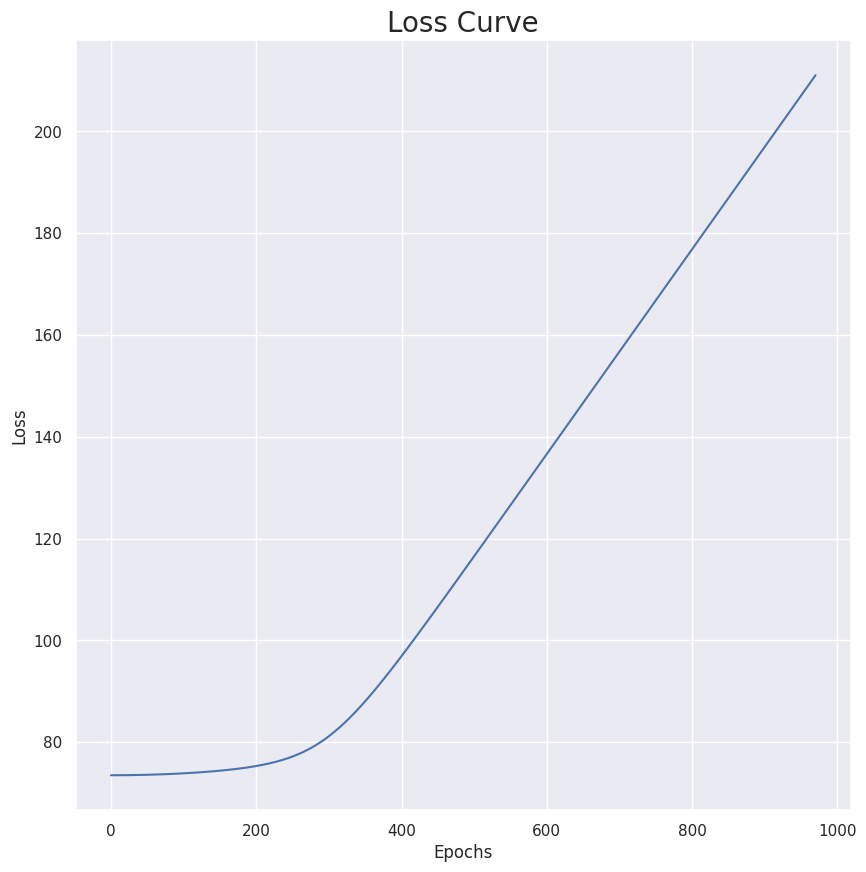

In [125]:
# train the model
# TODO
W, b, loss_list = logistic_regression(x_train, y_train) 
# plot the loss curve
# TODO
plt.title('Loss Curve', fontsize = 20) 
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.plot(loss_list)

### 3.5 Evaluation (10+1+4+3+2 = 20pts)

Write a function to predict the labels of X_test using the model trained above and return the predicted labels as categorical values similar to train labels. **(10pts)**

Note: By default, the predicted labels may return values within [0-6] instead of the original labels [3-9]. This can happen due to using argmax() to get label encoding from one-hot encoding when predicting test labels. You can add a simple offset to the argmax outputs of predicted labels to shift them to the range of [3-9]. This is important to note as you may see a very low accuracy even with a good model if true labels and predicted labels are not associated with the same categorical scale. 

In [173]:
def predict(X_test, W, b):
    '''
    X_test: a numpy array of testing features
    W: a numpy array of weights
    b: a numpy array of bias
    return: a numpy array of one-hot encoded labels
    '''
    # compute the scores
    # TODO
    test_scores = np.dot(X_test, W) + b

    # compute the probabilities
    # TODO
    probabilities = softmax(test_scores)
    
    # get the predicted labels
    # TODO
    predict = np.zeros([X_test.shape[0]])
    for i in range(len(probabilities)) :
      predict[i] = np.argmax(probabilities)
    
    labels = onehot(predict)
    # return the predicted labels
    # TODO
    return labels

**3.5.1** import accuracy_score, confusion_matrix, precision_score, recall_score and f1_score from scikitlearn **(1pts)**

In [157]:
# TODO
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

**3.5.2** Print the prediction scores on test data in terms of accuracy, precision and recall score. **(4pts)**

In [176]:
# TODO
predict = predict(x_test,W,b)
print("Accuracy Score: ",accuracy_score(y_test, predict))
print("Precision Score: ", precision_score(y_test, predict, average='weighted'))
print("Recall Score: ",(recall_score(y_test, predict, average='weighted') / 1) * 100)
print("f1 Score: ",(f1_score(y_test,predict, average='weighted') / 1) * 100) 


TypeError: ignored

**3.5.3** Generate and visualize the confusion matrix. You can use seaborn heatmap to visualize a heatmap of the confusion matrix. **(3pts)**

In [177]:
# TODO
cm = confusion_matrix(y_test, predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

TypeError: ignored

**3.5.4** Which labels seem to be harder to classify for this model? **(2pts)**

/ # TODO

###

## 4. Using Scikitlearn Logistic Regression (4+2+7+2 = 15pts)

### 4.1 Import LogisticRegressionCV module and create an instance of it. (4pts)
Use the following parameters:
1. 5-fold crossvalidation, 
2. lbfgs solver, 
3. run for 1000 iterations 
4. use 'multinomial' for choosing softmax classifier  

In [56]:
# TODO
from sklearn.linear_model import LogisticRegressionCV

clf = LogisticRegressionCV(cv=5, solver="lbfgs", max_iter=1000, multi_class='multinomial')

### 4.2 Train the model and predict the labels for test set. (2pts) 

In [57]:
# TODO
clf.fit(x_train, y_train)

/usr/local/lib/python3.9/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


LogisticRegressionCV(cv=5, max_iter=1000, multi_class='multinomial')

### 4.3 Compute the accuracy, precision, recall and F1 scores. Also visualize the confusion matrix. (1+1+1+1+3 =7pts) 

Accuracy Score:  0.5346153846153846
Precision Score:  0.5351204618031542
Recall Score:  53.46153846153846
f1 Score:  50.63778072895734


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


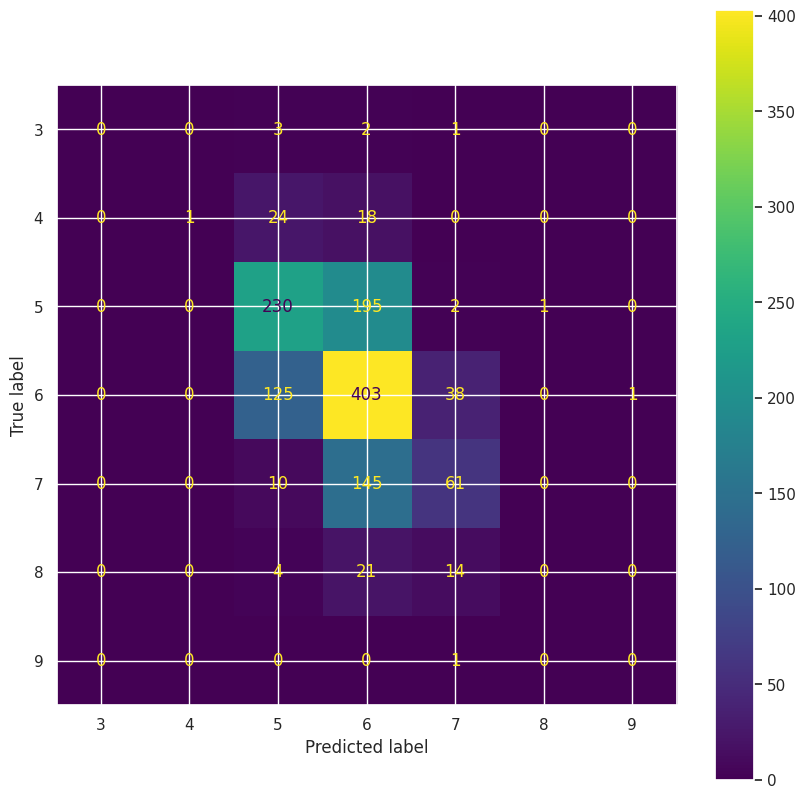

In [58]:
# TODO
y_pred = clf.predict(x_test)

print("Accuracy Score: ",accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall Score: ",(recall_score(y_test, y_pred, average='weighted') / 1) * 100)
print("f1 Score: ",(f1_score(y_test,y_pred, average='weighted') / 1) * 100) 


cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

plt.show()

### 4.4 Did your previous model (built from scratch) and the model from scikitlearn library produced similar evaluation scores? (2pts)

Explain (in <100 words) the similarity and dissimilarity in score. What changed, what didn't, and why?

/ # TODO

## 5. Using Scikitlearn Multi-layer Perceptron (16+19 = 35pts)

### 5.1 MLP with one hidden layer and stochastic gradient descent optimizer (4+2+1+7+2 = 16pts)

**5.1.1** Import MLPClassifier from scikitlearn's neural_network library. Then create a model instance of this classifier.

Use the following parameters: 
1. One hidden layer with 100 neurons, 
2. ReLu activation, 
3. Stochastic Gradient Descent solver
4. Learning rate = 0.01 (or you can continue to use your previous learning rate)
5. No of epoch = 1000

Also, set random_state to a fixed value so that your result is reproducible. **(4pts)** 

In [59]:
# TODO
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=100, activation='relu',solver='sgd', learning_rate_init=0.01, max_iter=1000, random_state=42)

**5.1.2** Train the model with training set.
Then predict the labels for test set. **(2pts)**

In [60]:
# TODO
mlp.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=100, learning_rate_init=0.01, max_iter=1000,
              random_state=42, solver='sgd')

**5.1.3** Plot the loss curve **(1pt)**

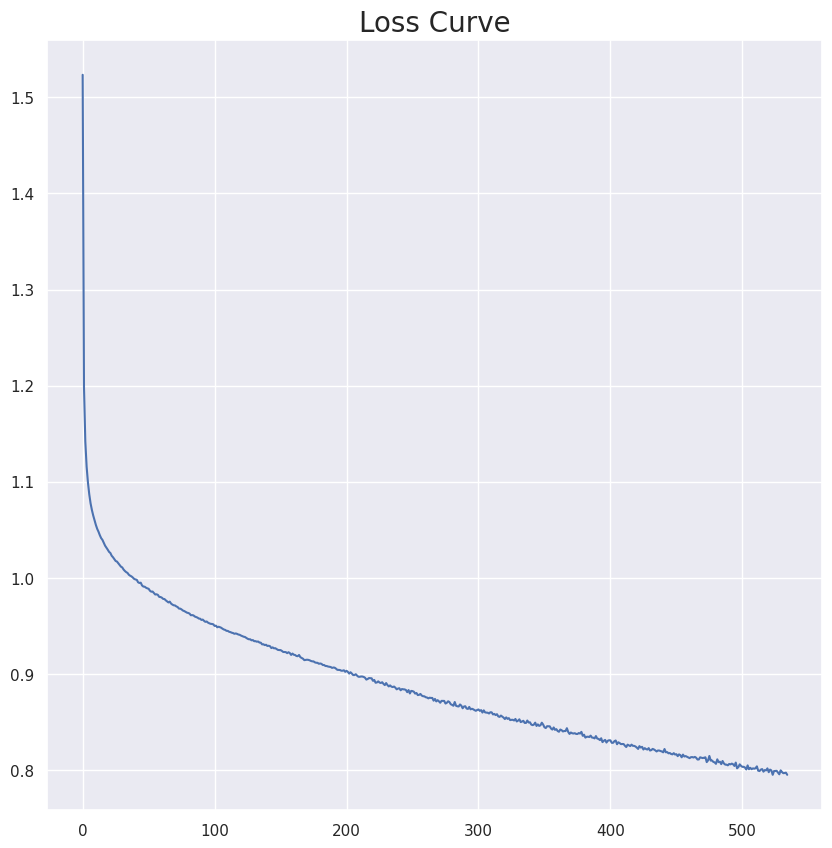

In [61]:
# TODO

plt.title('Loss Curve', fontsize = 20) 
plt.plot(mlp.loss_curve_)
plt.show()

**5.1.4** Print the accuracy, precision, recall and F1 scores. Also show the confusion matrix. **(1+1+1+1+3 = 7pts)**

Accuracy Score:  0.5615384615384615
Precision Score:  0.5503561827047087
Recall Score:  56.15384615384615
f1 Score:  54.416992025147316


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


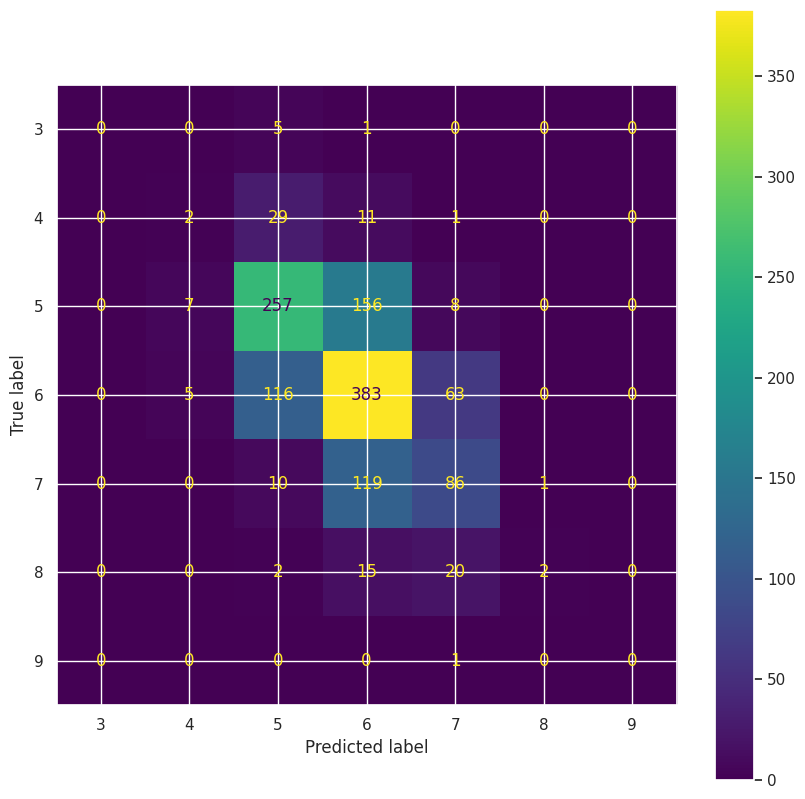

In [62]:
# TODO
y_pred = mlp.predict(x_test)

print("Accuracy Score: ",accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall Score: ",(recall_score(y_test, y_pred, average='weighted') / 1) * 100)
print("f1 Score: ",(f1_score(y_test,y_pred, average='weighted') / 1) * 100) 


cm = confusion_matrix(y_test, y_pred, labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot()

plt.show()

**5.1.5** Did you see any change in scores after using the MLP classifier?

In <100 words, describe your observation. **(2pts)**

/ # TODO

The MLP classifier seems to do a better job then the logistic regression CV. The accuracy and precision scores are both highter. Along with this, the f1 score and the recall score are also both higher with the MLP classifer. They have similar confusion matrices but the true values are closer to the predicted values for the MLP classifier.

### 5.2 MLP with two hidden layer and adam optimizer (4+2+1+7+2+3 = 19pts)

**5.2.1** Import MLPClassifier from scikitlearn's neural_network library. Then create a model instance of this classifier.

Use the following parameters: 
1. **Two** hidden layers with 100 neurons, 
2. ReLu activation, 
3. Adam solver (this is an advanced optimizer which we did not cover in class. However the usage is quite straightforward)
4. Learning rate = 0.01 (or you can continue to use your previous learning rate)
5. No of epoch = 1000

Also, set random_state to a fixed value so that your result is reproducible. **(4pts)** 

(Refer to the scikitlearn documentation for clarification on the parameters)

In [63]:
# TODO
mlp2 = MLPClassifier(hidden_layer_sizes=(100,100), activation='relu',solver='adam', learning_rate_init=0.01, max_iter=1000, random_state=42)

**5.2.2** Train the model with training set.
Then predict the labels for test set. **(2pts)**

In [64]:
# TODO
mlp2.fit(x_train, y_train)

MLPClassifier(hidden_layer_sizes=(100, 100), learning_rate_init=0.01,
              max_iter=1000, random_state=42)

**5.2.3** Plot the loss curve **(1pt)**

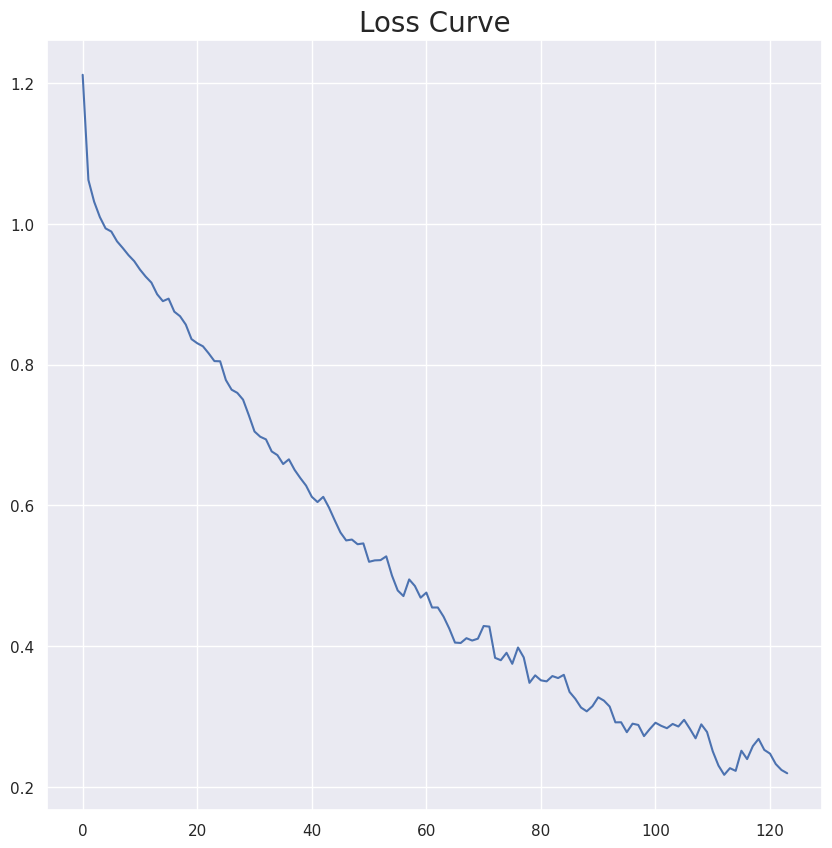

In [65]:
# TODO
plt.title('Loss Curve', fontsize = 20) 
plt.plot(mlp2.loss_curve_)
plt.show()

**5.2.4** Print the accuracy, precision, recall and F1 scores. Also show the confusion matrix. **(1+1+1+1+3 = 7pts)**

Accuracy Score:  0.6007692307692307
Precision Score:  0.6049328568331065
Recall Score:  60.07692307692307
f1 Score:  60.143431317381115


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


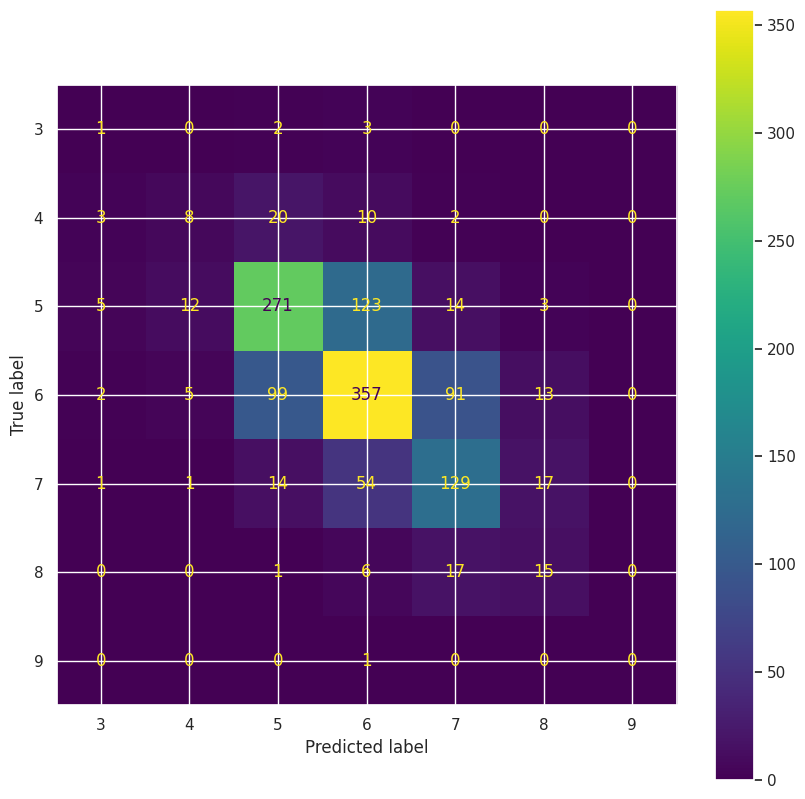

In [66]:
# TODO
y_pred = mlp2.predict(x_test)

print("Accuracy Score: ",accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall Score: ",(recall_score(y_test, y_pred, average='weighted') / 1) * 100)
print("f1 Score: ",(f1_score(y_test,y_pred, average='weighted') / 1) * 100) 


cm = confusion_matrix(y_test, y_pred, labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=mlp.classes_)
disp.plot()

plt.show()

**5.2.5** Describe any difference in the loss curve from MLP with one hidden layer and MLP with two hidden layer. **(2pts)**

/ # TODO

The loss curve for the MLP with 2 hidden layers shows more details. The curve is less of a straight line and is more jagged to better represent the data.

**5.2.6** Did you see any change in scores between the two MLP models?

In <100 words, describe your observation. **(3pts)**

/ # TODO

Between the two MLP models, the model with 2 hidden layers seems to do a way better job of learning and represnt the data. All the scores are better than the model with only one hidden layer and the confusion matrix shows the true valyues are much closer to the predicted values. 